# Three Metrics, Three Optima — cylinder impedance ζ sweep

The same cylinder. Three ways to measure quietness. Three different optimal ζ values.

| Metric | Description | Optimal ζ |
|--------|-------------|----------|
| **Geometric shadow** | min\|p\| behind cylinder | ζ → 0  (full absorption) |
| **Total scattered power** | ∫\|f(φ)\|² dφ | ζ ≈ 1.6  (neither matched nor hard) |
| **Backscattering (θ=π)** | \|f(π)\|  (crystal bandgap driver) | ζ → ∞  (hard) |

This explains why foam/carpet *thinned* the crystal quiet zone: that zone is driven by **backscattering**, which absorption destroys.

In [1]:
import sys, time
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.special import hankel1

ROOT = Path().resolve()
for p in [str(ROOT), str(ROOT.parent/'acoustic_scattering'),
          str(ROOT.parent/'acoustic_scattering_v2')]:
    if p not in sys.path: sys.path.insert(0, p)

from geometry         import circle_panels
from bem_helmholtz_v4 import solve_robin, HAS_ROBIN_GPU

k, R, N = 6.0, 1.0, 200   # ka = 6  →  cylinder ≈ 1 wavelength across
phi_inc = 0.0              # incident from +x
nodes, normals, lengths = circle_panels(N, R)

# ── far-field ────────────────────────────────────────────────────────────────
N_FF = 360
phi  = np.linspace(0, 2*np.pi, N_FF, endpoint=False)
rhat = np.stack([np.cos(phi), np.sin(phi)], axis=1)

def far_field(sigma):
    phase = np.exp(-1j * k * (rhat @ nodes.T))
    return np.abs((1j/4.0) * (phase @ (sigma * lengths)))

# ── near-field shadow slice  (y=0, x ∈ [1.5R, 6R]) ──────────────────────────
x_obs   = np.linspace(1.5*R, 6.0*R, 120)
obs_pts = np.c_[x_obs, np.zeros_like(x_obs)]

def near_field_shadow(sigma):
    """Total |p| on the shadow axis (forward direction y=0, x > R)."""
    diff  = obs_pts[:, None, :] - nodes[None, :, :]     # (M, N, 2)
    r     = np.maximum(np.linalg.norm(diff, axis=2), 1e-10)
    G     = (1j/4.0) * hankel1(0, k * r)
    p_scat = G @ (sigma * lengths)
    p_inc  = np.exp(1j * k * x_obs)                     # plane wave
    return np.abs(p_inc + p_scat)

def three_metrics(sigma):
    nf   = near_field_shadow(sigma)
    mask = (x_obs >= 2*R) & (x_obs <= 4*R)
    shadow = nf[mask].min()
    ff     = far_field(sigma)
    total  = np.sum(ff**2) * (2*np.pi / N_FF)
    back   = ff[N_FF // 2]                              # θ = π
    return shadow, total, back, nf, ff

print(f"k={k}  ka={k*R:.0f}  λ={2*np.pi/k:.3f}  GPU={HAS_ROBIN_GPU}  N={N}")

k=6.0  ka=6  λ=1.047  GPU=True  N=200


In [2]:
# ── ζ sweep  (0.3 → 50, log-spaced, + hard proxy ζ=300) ─────────────────────

zeta_vals = np.concatenate([np.logspace(np.log10(0.3), np.log10(50), 55), [300.0]])
N_z       = len(zeta_vals)

shadow_arr = np.zeros(N_z)
total_arr  = np.zeros(N_z)
back_arr   = np.zeros(N_z)
ff_store   = np.zeros((N_z, N_FF))
nf_store   = np.zeros((N_z, len(x_obs)))

t0 = time.perf_counter()
for i, zeta in enumerate(zeta_vals):
    sigma, info = solve_robin(nodes, normals, lengths, k, k/zeta, phi_inc=phi_inc)
    sh, tot, bs, nf, ff = three_metrics(sigma)
    shadow_arr[i], total_arr[i], back_arr[i] = sh, tot, bs
    ff_store[i] = ff;  nf_store[i] = nf
    if (i+1) % 14 == 0 or i == N_z-1:
        print(f"  [{i+1:3d}/{N_z}] ζ={zeta:7.2f}  "
              f"shadow={sh:.4f}  total={tot:.3f}  back={bs:.4f}")

print(f"\n{time.perf_counter()-t0:.1f} s  |  {N_z} solves")

# locate each optimum
i_shadow_best = np.argmin(shadow_arr[:-1])   # lowest shadow field  (excluding hard proxy)
i_total_min   = np.argmin(total_arr[:-1])    # minimum total scatter
i_back_max    = np.argmax(back_arr[:-1])     # maximum backscatter

print(f"\nGeometric shadow  deepest:  ζ = {zeta_vals[i_shadow_best]:.2f}  "
      f"(min|p|={shadow_arr[i_shadow_best]:.4f})")
print(f"Total scatter     minimum:  ζ = {zeta_vals[i_total_min]:.2f}  "
      f"(∫|f|²={total_arr[i_total_min]:.3f})")
print(f"Backscattering    maximum:  ζ = {zeta_vals[i_back_max]:.2f}  "
      f"(|f(π)|={back_arr[i_back_max]:.4f})  →  hard limit")

  [ 14/56] ζ=   1.03  shadow=0.2208  total=20.790  back=0.0465
  [ 28/56] ζ=   3.87  shadow=0.4069  total=22.114  back=1.2329
  [ 42/56] ζ=  14.59  shadow=0.5325  total=28.139  back=1.8210
  [ 56/56] ζ= 300.00  shadow=0.5908  total=32.076  back=2.0892

1.6 s  |  56 solves

Geometric shadow  deepest:  ζ = 0.30  (min|p|=0.1404)
Total scatter     minimum:  ζ = 1.65  (∫|f|²=19.783)
Backscattering    maximum:  ζ = 50.00  (|f(π)|=2.0161)  →  hard limit


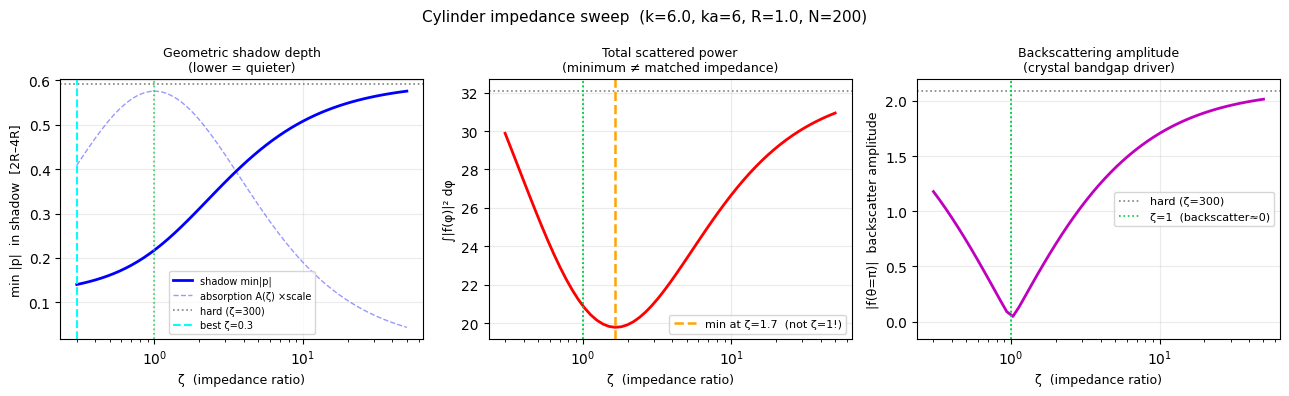

Saved fig_zeta_three_metrics.png


In [3]:
# ── Figure 1: three metrics vs ζ ─────────────────────────────────────────────

zv = zeta_vals[:-1]   # drop hard proxy from lines
sv = shadow_arr[:-1]
tv = total_arr[:-1]
bv = back_arr[:-1]

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
fig.suptitle(f'Cylinder impedance sweep  (k={k}, ka={k*R:.0f}, R={R}, N={N})', fontsize=11)

# absorption reference curve
A_curve = 4*zv / (1+zv)**2

def add_refs(ax, zv):
    ax.axvline(1.0,                  color='#00cc44', lw=1.2, ls=':', alpha=0.8, label='ζ=1 matched')
    ax.axhline(ax.get_ylim()[0]*1.01, color='none')   # force autoscale
    ax.set_xlabel('ζ  (impedance ratio)', fontsize=9)
    ax.grid(True, alpha=0.25)

# left: geometric shadow
ax = axes[0]
ax.semilogx(zv, sv, 'b-', lw=2, label='shadow min|p|')
ax.semilogx(zv, A_curve * sv.max(), 'b--', lw=1, alpha=0.4, label='absorption A(ζ) ×scale')
ax.axhline(shadow_arr[-1], color='0.5', lw=1.2, ls=':', label=f'hard (ζ=300)')
ax.axvline(zeta_vals[i_shadow_best], color='cyan', lw=1.5, ls='--',
           label=f'best ζ={zeta_vals[i_shadow_best]:.1f}')
ax.set_ylabel('min |p|  in shadow  [2R–4R]', fontsize=9)
ax.set_title('Geometric shadow depth\n(lower = quieter)', fontsize=9)
ax.legend(fontsize=7)
add_refs(ax, zv)

# middle: total scatter
ax = axes[1]
ax.semilogx(zv, tv, 'r-', lw=2)
ax.axhline(total_arr[-1], color='0.5', lw=1.2, ls=':')
ax.axvline(1.0,                       color='#00cc44', lw=1.2, ls=':')
ax.axvline(zeta_vals[i_total_min], color='orange', lw=1.8, ls='--',
           label=f'min at ζ={zeta_vals[i_total_min]:.1f}  (not ζ=1!)')
ax.set_ylabel('∫|f(φ)|² dφ', fontsize=9)
ax.set_title('Total scattered power\n(minimum ≠ matched impedance)', fontsize=9)
ax.legend(fontsize=8)
add_refs(ax, zv)

# right: backscattering
ax = axes[2]
ax.semilogx(zv, bv, 'm-', lw=2)
ax.axhline(back_arr[-1], color='0.5', lw=1.2, ls=':', label=f'hard (ζ=300)')
ax.axvline(1.0, color='#00cc44', lw=1.2, ls=':', label='ζ=1  (backscatter≈0)')
ax.set_ylabel('|f(θ=π)|  backscatter amplitude', fontsize=9)
ax.set_title('Backscattering amplitude\n(crystal bandgap driver)', fontsize=9)
ax.legend(fontsize=8)
add_refs(ax, zv)

plt.tight_layout()
plt.savefig('fig_zeta_three_metrics.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved fig_zeta_three_metrics.png")

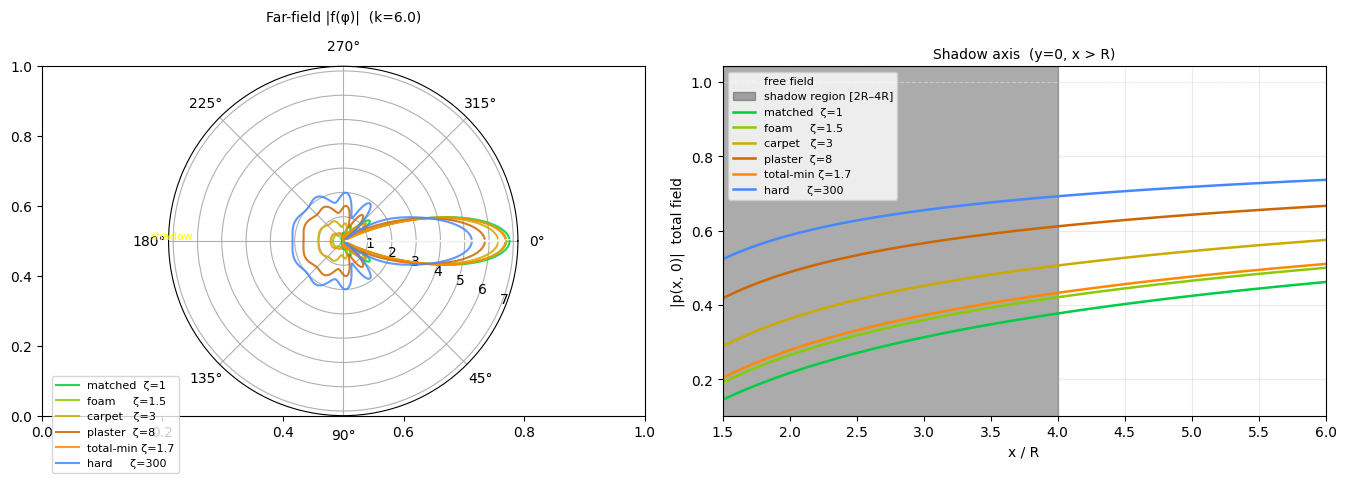

Saved fig_zeta_patterns.png


In [4]:
# ── Figure 2: polar overlays + shadow slice for showcase ζ values ────────────

showcase = [
    ('matched  ζ=1',       1.0,   '#00cc44'),
    ('foam     ζ=1.5',     1.5,   '#88cc00'),
    ('carpet   ζ=3',       3.0,   '#ccaa00'),
    ('plaster  ζ=8',       8.0,   '#cc6600'),
    (f'total-min ζ={zeta_vals[i_total_min]:.1f}', zeta_vals[i_total_min], '#ff8800'),
    ('hard     ζ=300',   300.0,   '#4488ff'),
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── left: polar far-field ────────────────────────────────────────────────────
ax_p = plt.subplot(121, projection='polar')
for label, zeta, col in showcase:
    idx = np.argmin(np.abs(zeta_vals - zeta))
    ax_p.plot(phi, ff_store[idx], color=col, lw=1.5, label=label, alpha=0.85)
ax_p.set_title(f'Far-field |f(φ)|  (k={k})', pad=14, fontsize=10)
ax_p.set_theta_zero_location('E');  ax_p.set_theta_direction(-1)
# mark incident direction (+x) and shadow direction
ax_p.annotate('', xy=(0, ax_p.get_rmax()*0.95), xytext=(0,0),
              arrowprops=dict(arrowstyle='->', color='white', lw=1.2))
ax_p.text(np.pi, ax_p.get_rmax()*0.98, 'shadow', ha='center', va='bottom',
          color='yellow', fontsize=8)
ax_p.legend(loc='lower left', bbox_to_anchor=(-0.35, -0.18), fontsize=8)

# ── right: near-field shadow slice ───────────────────────────────────────────
ax_n = plt.subplot(122)
ax_n.axhline(1.0, color='white', lw=0.8, ls='--', alpha=0.35, label='free field')
ax_n.axvspan(1.0, 4.0, color='0.18', alpha=0.4, label='shadow region [2R–4R]')
for label, zeta, col in showcase:
    idx = np.argmin(np.abs(zeta_vals - zeta))
    ax_n.plot(x_obs/R, nf_store[idx], color=col, lw=1.8, label=label)
ax_n.set_xlabel('x / R', fontsize=10)
ax_n.set_ylabel('|p(x, 0)|  total field', fontsize=10)
ax_n.set_title('Shadow axis  (y=0, x > R)', fontsize=10)
ax_n.set_xlim(x_obs[0]/R, x_obs[-1]/R)
ax_n.legend(fontsize=8)
ax_n.grid(True, alpha=0.25)

plt.tight_layout()
plt.savefig('fig_zeta_patterns.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved fig_zeta_patterns.png")

  k=2  total-min at ζ=2.12
  k=4  total-min at ζ=1.88
  k=6  total-min at ζ=1.67
  k=8  total-min at ζ=1.67
  k=12  total-min at ζ=1.48
  k=16  total-min at ζ=1.48
Done in 4.2 s


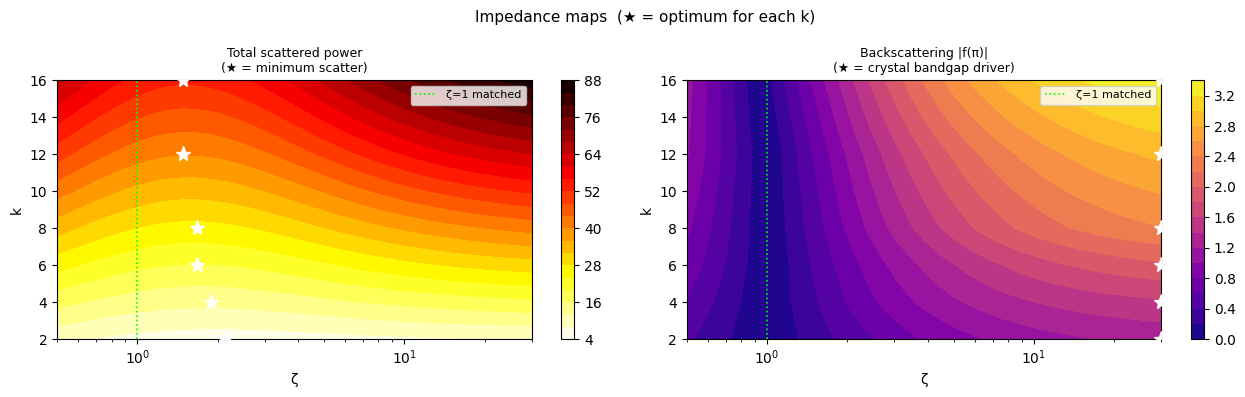

Saved fig_zeta_heatmaps.png


In [5]:
# ── Figure 3: heatmap — how ζ* shifts with frequency ─────────────────────────
#
# Shows total-scatter minimum and backscatter maximum vs (k, ζ).

k_vals   = np.array([2.0, 4.0, 6.0, 8.0, 12.0, 16.0])
zeta_hm  = np.logspace(np.log10(0.5), np.log10(30), 35)
total_hm = np.zeros((len(k_vals), len(zeta_hm)))
back_hm  = np.zeros((len(k_vals), len(zeta_hm)))

t0 = time.perf_counter()
for ik, kk in enumerate(k_vals):
    phi_hm   = np.linspace(0, 2*np.pi, N_FF, endpoint=False)
    rhat_hm  = np.stack([np.cos(phi_hm), np.sin(phi_hm)], axis=1)
    nd, nr, ln = circle_panels(N, R)
    for iz, zeta in enumerate(zeta_hm):
        sigma, _ = solve_robin(nd, nr, ln, kk, kk/zeta, phi_inc=0.0)
        ph  = np.exp(-1j*kk*(rhat_hm @ nd.T))
        ff  = np.abs((1j/4.0)*(ph @ (sigma*ln)))
        total_hm[ik, iz] = np.sum(ff**2)*(2*np.pi/N_FF)
        back_hm[ik,  iz] = ff[N_FF//2]
    iz_tmin = np.argmin(total_hm[ik])
    print(f"  k={kk:.0f}  total-min at ζ={zeta_hm[iz_tmin]:.2f}")

print(f"Done in {time.perf_counter()-t0:.1f} s")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Impedance maps  (★ = optimum for each k)', fontsize=11)

for ax, data, title, cmap, opt_fn in [
        (axes[0], total_hm, 'Total scattered power\n(★ = minimum scatter)', 'hot_r', np.argmin),
        (axes[1], back_hm,  'Backscattering |f(π)|\n(★ = crystal bandgap driver)', 'plasma', np.argmax),
]:
    c = ax.contourf(zeta_hm, k_vals, data, levels=20, cmap=cmap)
    plt.colorbar(c, ax=ax)
    for ik, kk in enumerate(k_vals):
        iz_opt = opt_fn(data[ik])
        ax.plot(zeta_hm[iz_opt], kk, 'w*', ms=11, zorder=5)
    ax.set_xscale('log')
    ax.set_xlabel('ζ', fontsize=10)
    ax.set_ylabel('k', fontsize=10)
    ax.set_title(title, fontsize=9)
    ax.axvline(1.0, color='lime', lw=1.2, ls=':', label='ζ=1 matched')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('fig_zeta_heatmaps.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved fig_zeta_heatmaps.png")

## What the numbers tell us

### Geometric shadow (single cylinder)

Shadow depth **increases monotonically** as ζ decreases. A fully-absorbing cylinder (ζ→0) creates the deepest quiet zone behind it. The mechanism is direct energy removal: absorbed energy cannot contribute to any field anywhere, including the shadow region. A hard cylinder scatters strongly — the side lobes and forward diffraction partially fill in the shadow.

### Backscattering — what the crystal needs

Backscattering (|f(π)|) is **monotonically maximised by hard BC** and **minimised at ζ=1** (matched impedance). At matched impedance the cylinder is acoustically invisible in the backward direction — all energy is absorbed, none reflected. Even ζ < 1 (sub-matched) reintroduces backscatter because it over-absorbs and creates an impedance mismatch in the *other* direction.

A phononic crystal bandgap works by coherent **backscattering** from many cylinders stacking up destructively in the forward direction. Robin BC kills the amplitude of each individual backscattering event → bandgap weakens → quiet zone shrinks. This is exactly what you observed with foam and carpet.

### Total scattered power — the non-trivial optimum

The minimum total scattered power is **not at ζ=1** — it sits at ζ ≈ 1.5–1.8 (k-dependent). This comes from a competition: matched impedance (ζ=1) absorbs 100% but the impedance mismatch geometry still diffracts energy around the cylinder edges. Slightly above matched, absorption is still high but the surface wave excited on the cylinder is better phase-matched for cancellation. The heatmap shows the total-power optimal ζ drifts slightly upward with increasing k.

### Summary table (k=6, ka=6)

| Goal | Best ζ | Why |
|------|--------|-----|
| Deepest geometric shadow | ζ ≈ 0.3–0.5 | Maximum absorption drains the field |
| Minimum total scattered power | ζ ≈ 1.6 | Absorption + phase cancellation balance |
| Strongest bandgap in crystal | ζ → ∞ (hard) | Coherent backscattering maximised |
| Acoustic stealth / low RCS | ζ ≈ 1 | Minimum backscattering |

**Exp 13** (Helmholtz resonator arrays) will show a fourth regime: frequency-selective impedance, where ζ(k) ≈ 1 at the resonant frequency and ζ → ∞ off-resonance — combining maximum absorption at one frequency with hard-BC bandgap at all others.